# ML Analysis — League of Legends Dataset

This notebook consists of two main sections:

Supervised Learning: Win prediction (Logistic Regression vs Decision Tree vs Random Forest vs KNN)

Unsupervised Learning: Match archetypes (K-Means) + Feature visualization (PCA)

## 0. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics         import (
    accuracy_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv('lol_dataset.csv')

# Group map (kendi hesapların)
MINE = ['StârMuhtar', 'FrozênMuhtar', 'freak999', 'JPL']
df['group'] = df['player'].apply(lambda x: 'mine' if x in MINE else 'friends')

# Rank order
RANK_ORDER = ['Iron','Bronze','Silver','Gold','Platinum','Emerald','Diamond','Master','GrandMaster','Challenger']
df['rank_num'] = df['rank'].map({r: i for i, r in enumerate(RANK_ORDER)})

# Temizlik: 10-70 dk arası maçlar
df = df[(df['duration_min'] >= 10) & (df['duration_min'] <= 70)].copy()
df = df.dropna(subset=['win', 'dragon_adv', 'baron_adv', 'tower_adv'])

print(f'Total matches: {len(df)}')
print(f'Win rate:   {df["win"].mean():.3f}')
print(f'Ranks:      {df["rank"].unique()}')
df.head(3)

Total matches: 5044
Win rate:   0.520
Ranks:      ['Emerald' 'Master' 'Platinum' 'Diamond' 'Iron' 'Bronze' 'Silver' 'Gold'
 'GrandMaster' 'Challenger']


,match_id,patch,player,rank,champion,role,win,duration_min,first_tower,first_dragon,...,kills,deaths,assists,kda,damage,gold,cs,vision_score,group,rank_num
0,TR1_1702205429,16.07,StârMuhtar,Emerald,Sion,TOP,1,32.500000,0,0,...,5,5,23,5.600000,34648,13239,195,20,mine,5
1,TR1_1702182126,16.07,StârMuhtar,Emerald,Yone,MIDDLE,1,34.783333,0,0,...,10,13,12,1.692308,43779,16376,249,22,mine,5
2,TR1_1697065689,16.05,StârMuhtar,Emerald,LeeSin,JUNGLE,0,25.750000,0,0,...,9,10,9,1.800000,19678,12047,161,13,mine,5


---
# PART 1 — SUPERVISED LEARNING: Win Prediction

**Goal:** Predict `win` variable

**Features:** Objective control (dragon, baron, tower, rift herald) + player statistics

**Models:** Logistic Regression · Decision Tree · Random Forest · KNN

### 1.1 Feature Preparing

In [4]:
FEATURES = [
    'first_dragon', 'first_baron', 'first_tower', 'first_riftherald',
    'dragon_adv', 'baron_adv', 'tower_adv',
    'kda', 'gold', 'cs', 'vision_score', 'damage', 'duration_min', 'rank_num'
]

df_ml = df[FEATURES + ['win', 'player', 'rank']].dropna().copy()

X = df_ml[FEATURES].values
y = df_ml['win'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Features: {FEATURES}')

Train: 4035 | Test: 1009
Features: ['first_dragon', 'first_baron', 'first_tower', 'first_riftherald', 'dragon_adv', 'baron_adv', 'tower_adv', 'kda', 'gold', 'cs', 'vision_score', 'damage', 'duration_min', 'rank_num']


### 1.2 Model Training & Comperison

In [5]:
from sklearn.model_selection import StratifiedKFold

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
    'KNN (K=15)':          KNeighborsClassifier(n_neighbors=15),
}

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained = {}

for name, model in models.items():
    use_scaled = name in ['Logistic Regression', 'KNN (K=15)']
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    trained[name] = (model, use_scaled)

    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    cv_scores = cross_val_score(model, Xtr, y_train, cv=skf, scoring='roc_auc')

    results.append({
        'Model':       name,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'AUC':         round(roc_auc_score(y_test, y_proba), 4),
        'CV AUC Mean': round(cv_scores.mean(), 4),
        'CV AUC Std':  round(cv_scores.std(), 4),
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy    AUC  CV AUC Mean  CV AUC Std
Logistic Regression    0.9673 0.9935       0.9940      0.0020
      Random Forest    0.9643 0.9919       0.9939      0.0017
         KNN (K=15)    0.9336 0.9844       0.9816      0.0036
      Decision Tree    0.9574 0.9842       0.9829      0.0055


### 1.3 Model Comperison Images

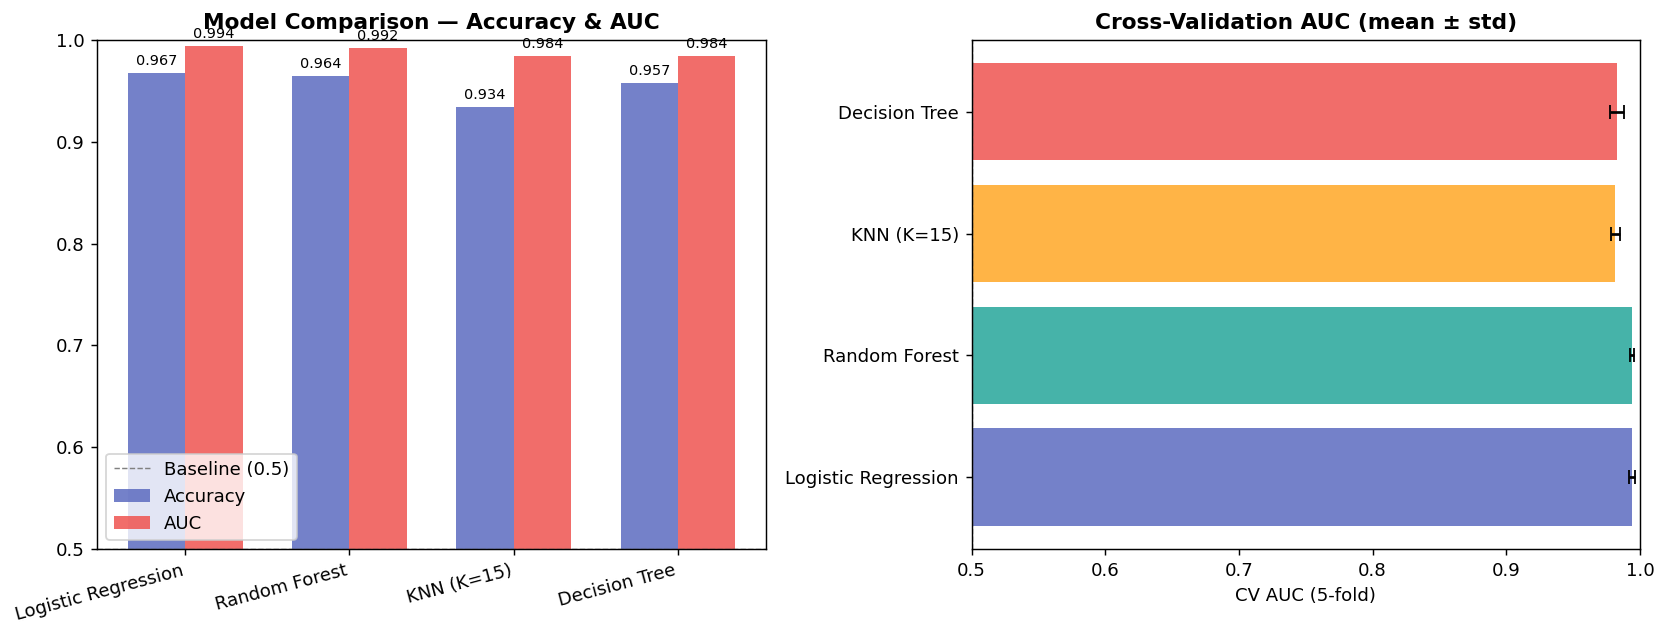

[+] model_comparison.png kaydedildi


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol: Accuracy & AUC bar
x   = np.arange(len(results_df))
w   = 0.35
ax  = axes[0]
ax.bar(x - w/2, results_df['Accuracy'], w, label='Accuracy', color='#5C6BC0', alpha=0.85)
ax.bar(x + w/2, results_df['AUC'],      w, label='AUC',      color='#EF5350', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Baseline (0.5)')
ax.set_title('Model Comparison — Accuracy & AUC', fontweight='bold')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Sağ: CV AUC (mean ± std)
ax2 = axes[1]
colors = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']
ax2.barh(results_df['Model'], results_df['CV AUC Mean'],
         xerr=results_df['CV AUC Std'], color=colors, alpha=0.85,
         error_kw={'elinewidth': 1.5, 'capsize': 4})
ax2.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('CV AUC (5-fold)')
ax2.set_title('Cross-Validation AUC (mean ± std)', fontweight='bold')
ax2.set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[+] model_comparison.png kaydedildi')

### 1.4 ROC Curves

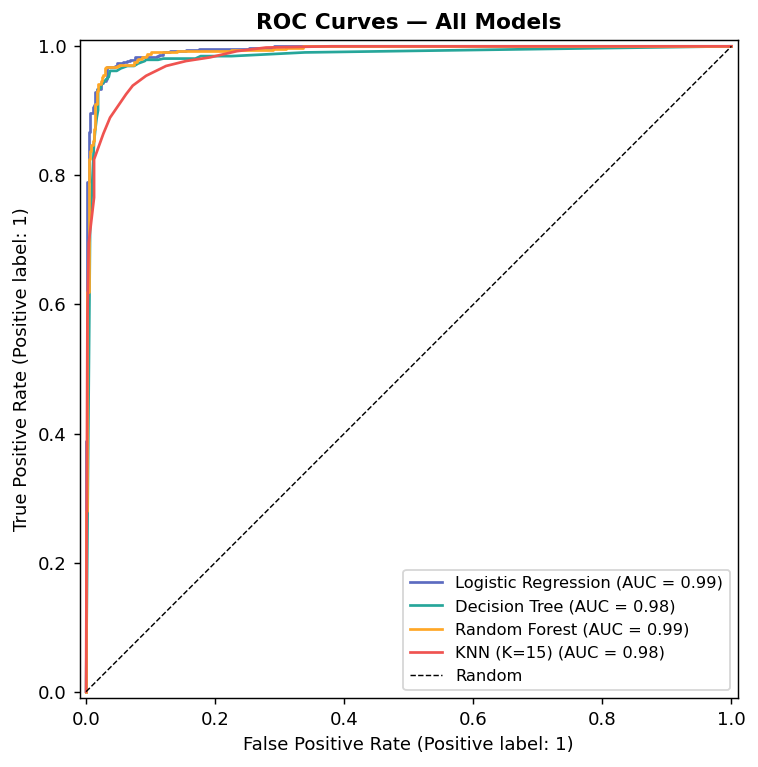

[+] roc_curves.png kaydedildi


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']

for (name, (model, use_scaled)), color in zip(trained.items(), colors_roc):
    Xte = X_test_sc if use_scaled else X_test
    RocCurveDisplay.from_estimator(model, Xte, y_test, ax=ax, name=name, color=color)

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print('[+] roc_curves.png kaydedildi')

### 1.5 Random Forest — Feature Importance

> Which variable determines winning the most?

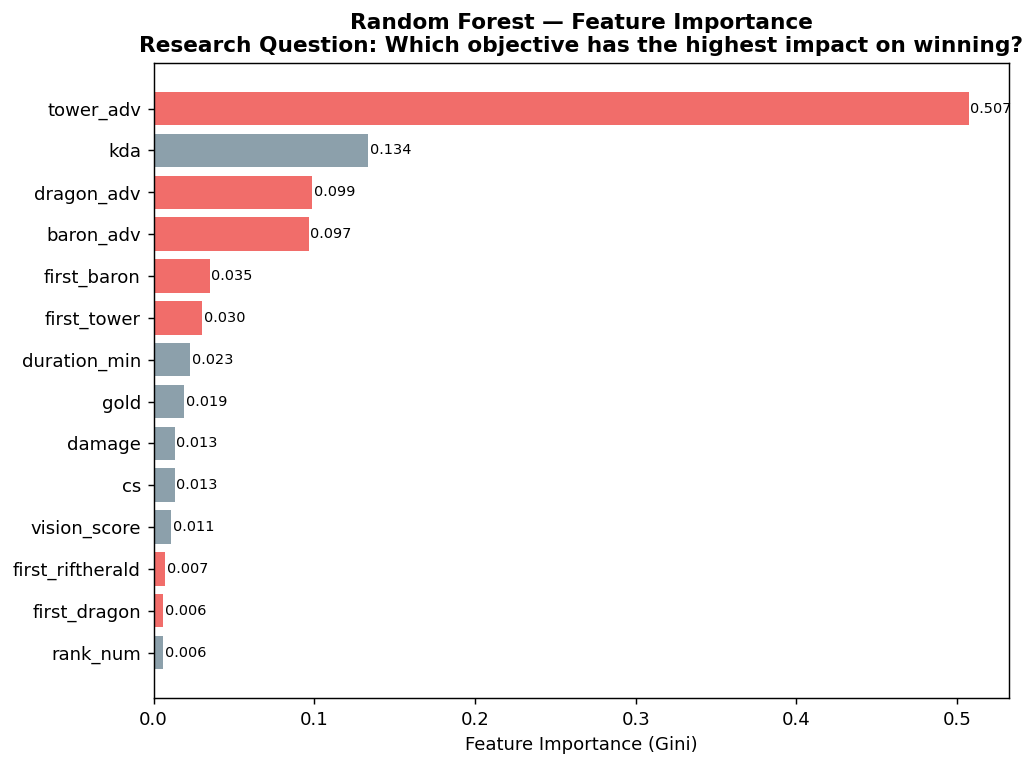

[+] feature_importance.png kaydedildi

Top 3 Most Important Features: ['dragon_adv', 'kda', 'tower_adv']
→ These features have the highest impact on winning.


In [8]:
rf_model = trained['Random Forest'][0]

importance_df = pd.DataFrame({
    'feature':   FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_fi = ['#EF5350' if 'adv' in f or 'first' in f else '#78909C' for f in importance_df['feature']]
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors_fi, alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(
    'Random Forest — Feature Importance\n'
    'Research Question: Which objective has the highest impact on winning?',
    fontweight='bold'
)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('[+] feature_importance.png kaydedildi')

top3 = importance_df.tail(3)['feature'].tolist()
print(f"\nTop 3 Most Important Features: {top3}")
print("→ These features have the highest impact on winning.")

In [9]:
### 1.5.2 Objective only vs full model

In [10]:
# Sadece objective feature'larla model
OBJ_ONLY = ['first_dragon','first_baron','first_tower','first_riftherald',
            'dragon_adv','baron_adv','tower_adv']

rf_obj  = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_full = trained['Random Forest'][0]

cv_obj  = cross_val_score(rf_obj,  df_ml[OBJ_ONLY].values, y, cv=skf, scoring='roc_auc')
cv_full = cross_val_score(rf_full, X, y,                    cv=skf, scoring='roc_auc')

print(f"Sadece Objective Features  → AUC: {cv_obj.mean():.4f} ± {cv_obj.std():.4f}")
print(f"All Features               → AUC: {cv_full.mean():.4f} ± {cv_full.std():.4f}")
print(f"\nThe proportion of performance variance explained solely by objectives: "
      f"{cv_obj.mean()/cv_full.mean():.1%}")

Sadece Objective Features  → AUC: 0.9925 ± 0.0015
All Features               → AUC: 0.9932 ± 0.0014

The proportion of performance variance explained solely by objectives: 99.9%


### 1.6 KNN — Optimal K Choice

En iyi K: 15 (AUC: 0.9812)


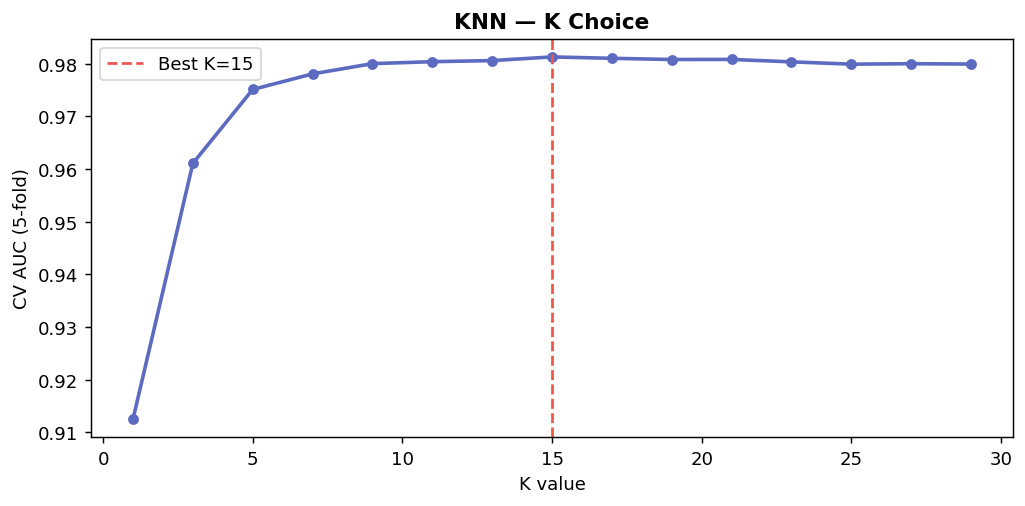

[+] knn_k_selection.png kaydedildi


In [11]:
k_values = range(1, 31, 2)  # 1,3,5,...,29
auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='roc_auc')
    auc_scores.append(scores.mean())

best_k = list(k_values)[np.argmax(auc_scores)]
print(f'En iyi K: {best_k} (AUC: {max(auc_scores):.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_values), auc_scores, 'o-', color='#5C6BC0', linewidth=2, markersize=5)
ax.axvline(best_k, color='#EF5350', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
ax.set_xlabel('K value')
ax.set_ylabel('CV AUC (5-fold)')
ax.set_title('KNN — K Choice', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150)
plt.show()
print('[+] knn_k_selection.png kaydedildi')

### 1.7 Decision Tree — Visualization

> Human-interpretable rules.

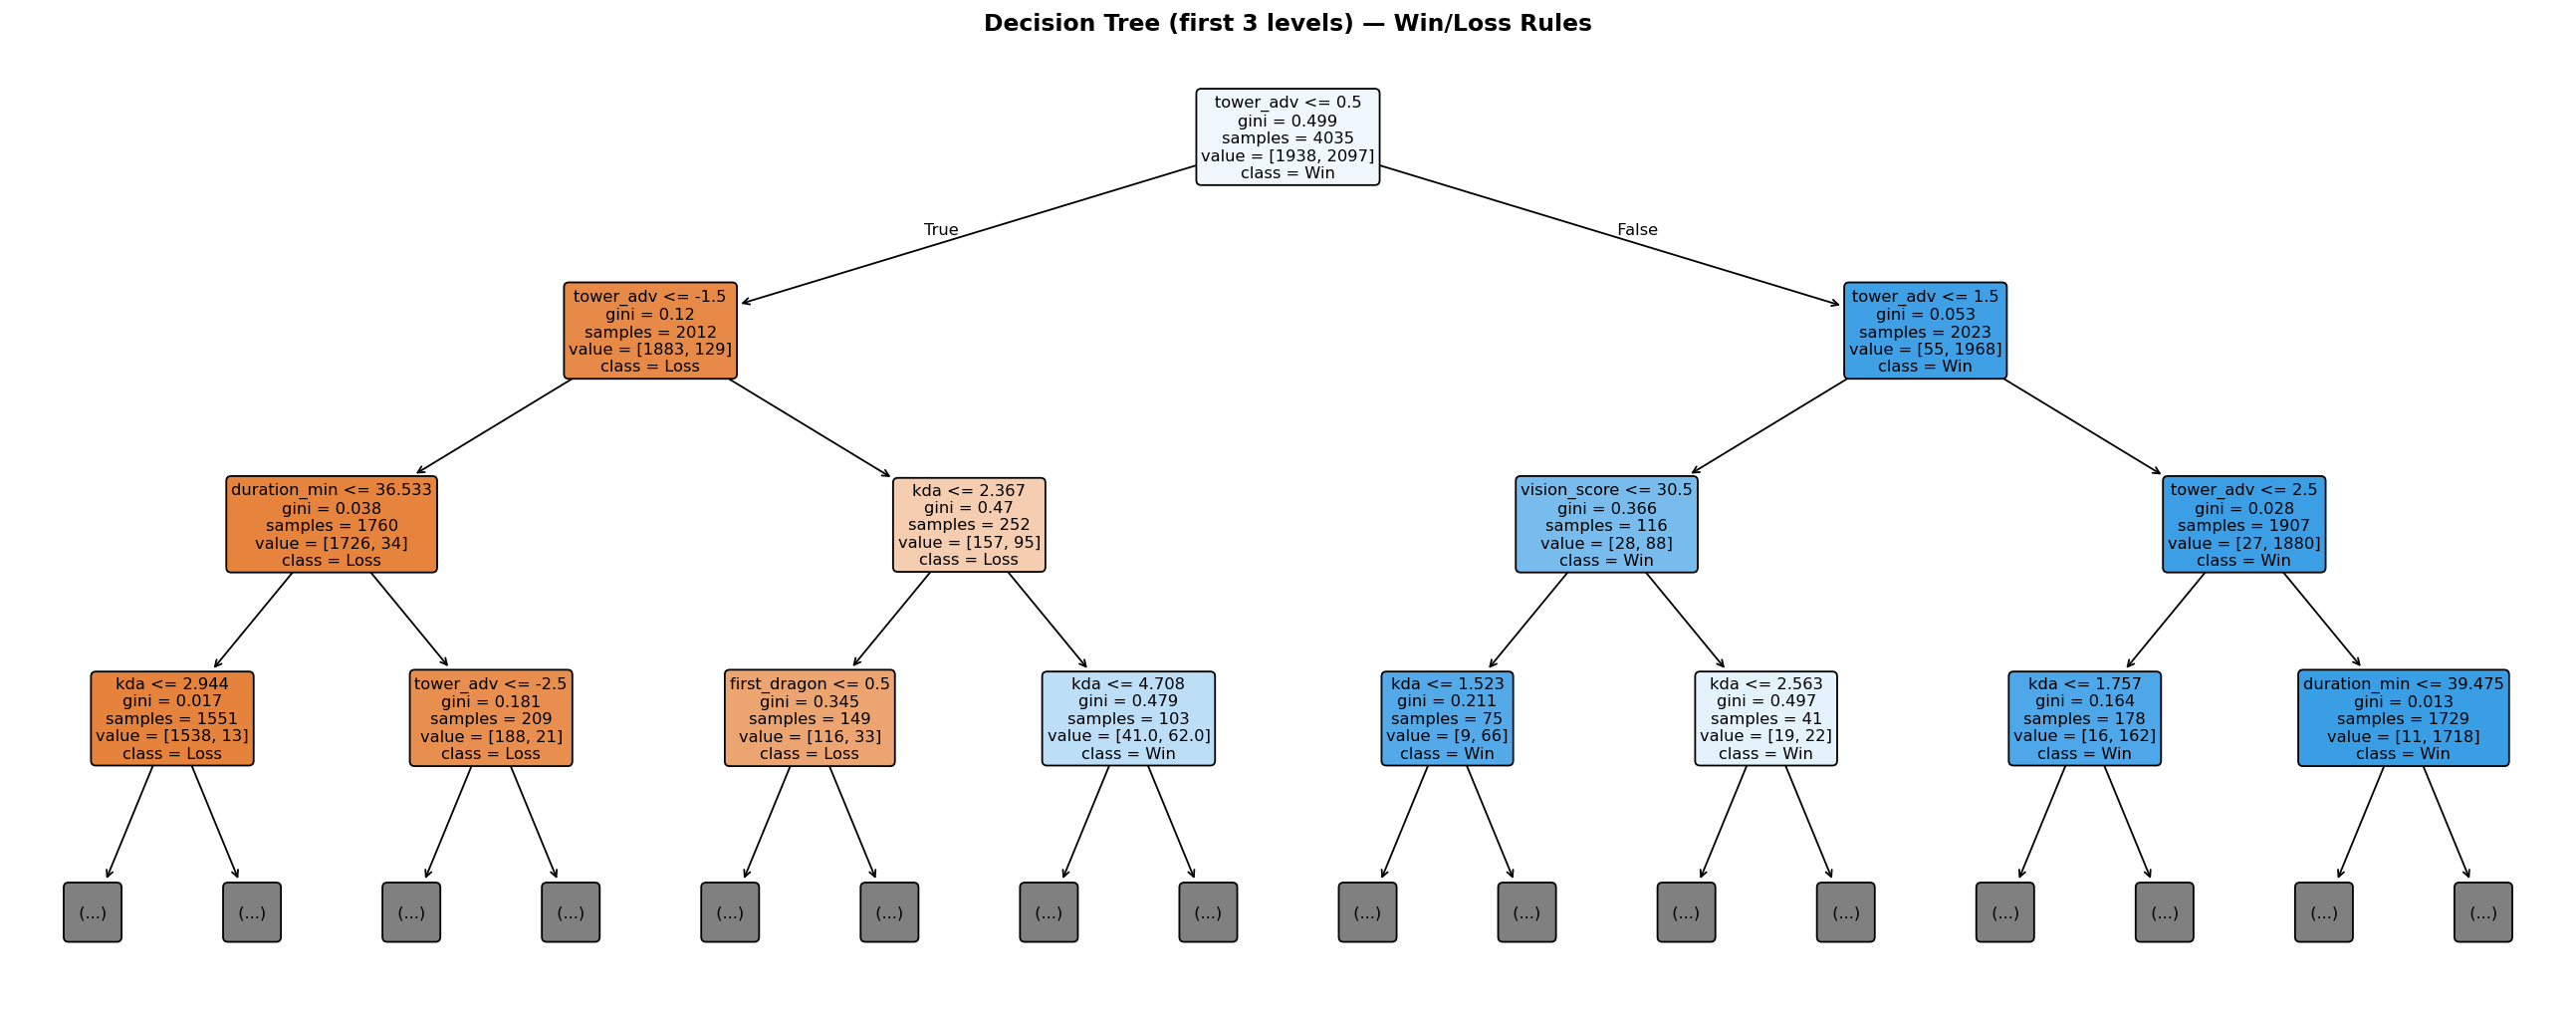

[+] decision_tree.png kaydedildi


In [12]:
dt_model = trained['Decision Tree'][0]

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=FEATURES,
    class_names=['Loss', 'Win'],
    max_depth=3,   # Sadece ilk 3 katmanı göster, okunabilirlik için
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree (first 3 levels) — Win/Loss Rules', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print('[+] decision_tree.png kaydedildi')

### Rank-Based Model Performance

> Analyze in which rank Random Forest performs better.

       rank    AUC   n
       Iron 1.0000 211
     Bronze 0.9983 478
     Silver 0.9992 472
       Gold 0.9950 486
   Platinum 0.9987 779
    Emerald 0.9984 585
    Diamond 0.9985 635
     Master 0.9988 412
GrandMaster 0.9947 495
 Challenger 0.9998 491


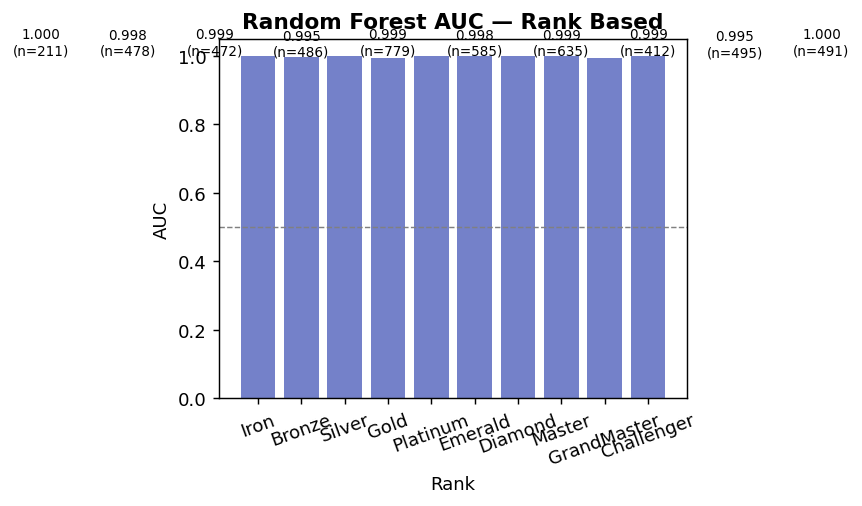

In [13]:
rf = trained['Random Forest'][0]
rank_perf = []

for rank in RANK_ORDER:
    sub = df_ml[df_ml['rank'] == rank]
    if len(sub) < 40:
        continue
    X_r = sub[FEATURES].values
    y_r = sub['win'].values
    y_proba_r = rf.predict_proba(X_r)[:, 1]
    auc_r = roc_auc_score(y_r, y_proba_r) if len(np.unique(y_r)) > 1 else np.nan
    rank_perf.append({'rank': rank, 'AUC': round(auc_r, 4), 'n': len(sub)})

rp_df = pd.DataFrame(rank_perf)
print(rp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rp_df['rank'], rp_df['AUC'], color='#5C6BC0', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('AUC')
ax.set_xlabel('Rank')
ax.set_title('Random Forest AUC — Rank Based', fontweight='bold')
for i, row in rp_df.iterrows():
    ax.text(i - len(rp_df)//2 + i, row['AUC'] + 0.005,
            f"{row['AUC']:.3f}\n(n={row['n']})", ha='center', fontsize=7.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('rf_by_rank.png', dpi=150)
plt.show()

---
# PART 2 — UNSUPERVISED LEARNING

**2A — K-Means Clustering: Discover match archetypes (are there different types of matches?)

**2B — PCA: Visualize the feature structure in 2D

### 2.1 K-Means — Feature Choice & Normalization

In [14]:
# Clustering için objective + oyun dinamiği feature'ları
CLUSTER_FEATURES = [
    'dragon_adv', 'baron_adv', 'tower_adv',
    'duration_min', 'gold', 'kda', 'vision_score'
]

df_cl = df[CLUSTER_FEATURES + ['win', 'rank', 'player']].dropna().copy()
X_cl  = df_cl[CLUSTER_FEATURES].values

scaler_cl = StandardScaler()
X_cl_sc   = scaler_cl.fit_transform(X_cl)

print(f'For clustering, {len(df_cl)} matches are being used.')

For clustering, 5044 matches are being used.


### 2.2 Optimal K — Elbow Method

  File "c:\Users\hayre\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\hayre\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hayre\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hayre\anaconda3\Lib\subprocess.

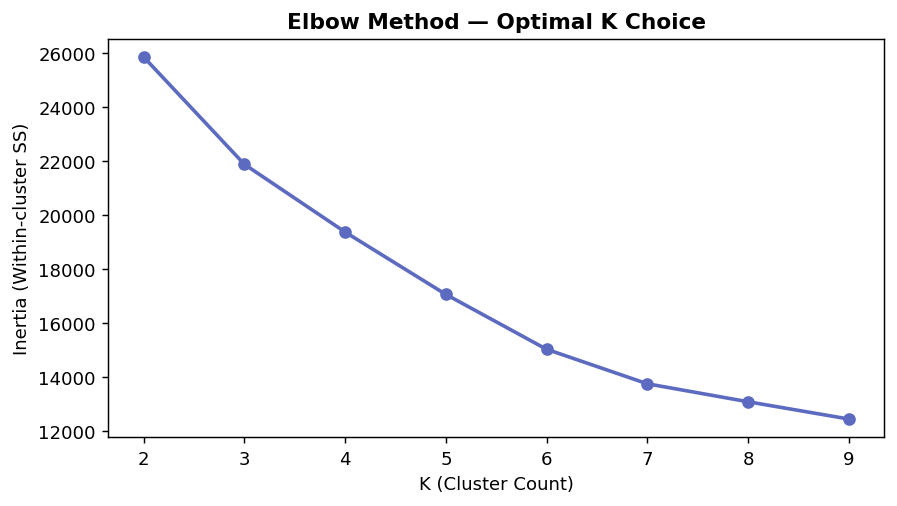

[+] elbow.png kaydedildi
Elbow grafiğine bakarak en uygun K değerini seç (dirsek noktası)


In [15]:
inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cl_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'o-', color='#5C6BC0', linewidth=2, markersize=6)
ax.set_xlabel('K (Cluster Count)')
ax.set_ylabel('Inertia (Within-cluster SS)')
ax.set_title('Elbow Method — Optimal K Choice', fontweight='bold')
plt.tight_layout()
plt.savefig('elbow.png', dpi=150)
plt.show()
print('[+] elbow.png kaydedildi')
print('Elbow grafiğine bakarak en uygun K değerini seç (dirsek noktası)')

### 2.3 K-Means Application (K=4)

In [16]:
K_OPTIMAL = 4  # Elbow grafiğine göre değiştir

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df_cl['cluster'] = km_final.fit_predict(X_cl_sc)

# Her kümenin ortalama istatistikleri
cluster_summary = df_cl.groupby('cluster').agg(
    n_matches      = ('win', 'count'),
    win_rate       = ('win', 'mean'),
    avg_duration   = ('duration_min', 'mean'),
    avg_dragon_adv = ('dragon_adv', 'mean'),
    avg_baron_adv  = ('baron_adv', 'mean'),
    avg_tower_adv  = ('tower_adv', 'mean'),
    avg_gold       = ('gold', 'mean'),
    avg_kda        = ('kda', 'mean'),
).round(3)

print('Cluster Summary:')
print(cluster_summary.to_string())

Cluster Summary:
         n_matches  win_rate  avg_duration  avg_dragon_adv  avg_baron_adv  avg_tower_adv   avg_gold  avg_kda
cluster                                                                                                     
0             1124     0.099        22.977          -1.506         -0.251         -5.230   8348.610    1.187
1             1227     0.824        35.373           1.258          0.993          3.640  16050.413    3.306
2             1350     0.997        25.346           1.926          0.495          6.781  11943.667    6.175
3             1343     0.115        33.364          -1.388         -0.978         -4.617  13822.640    2.043


### 2.4 Cluster Visualization & Archetype Naming

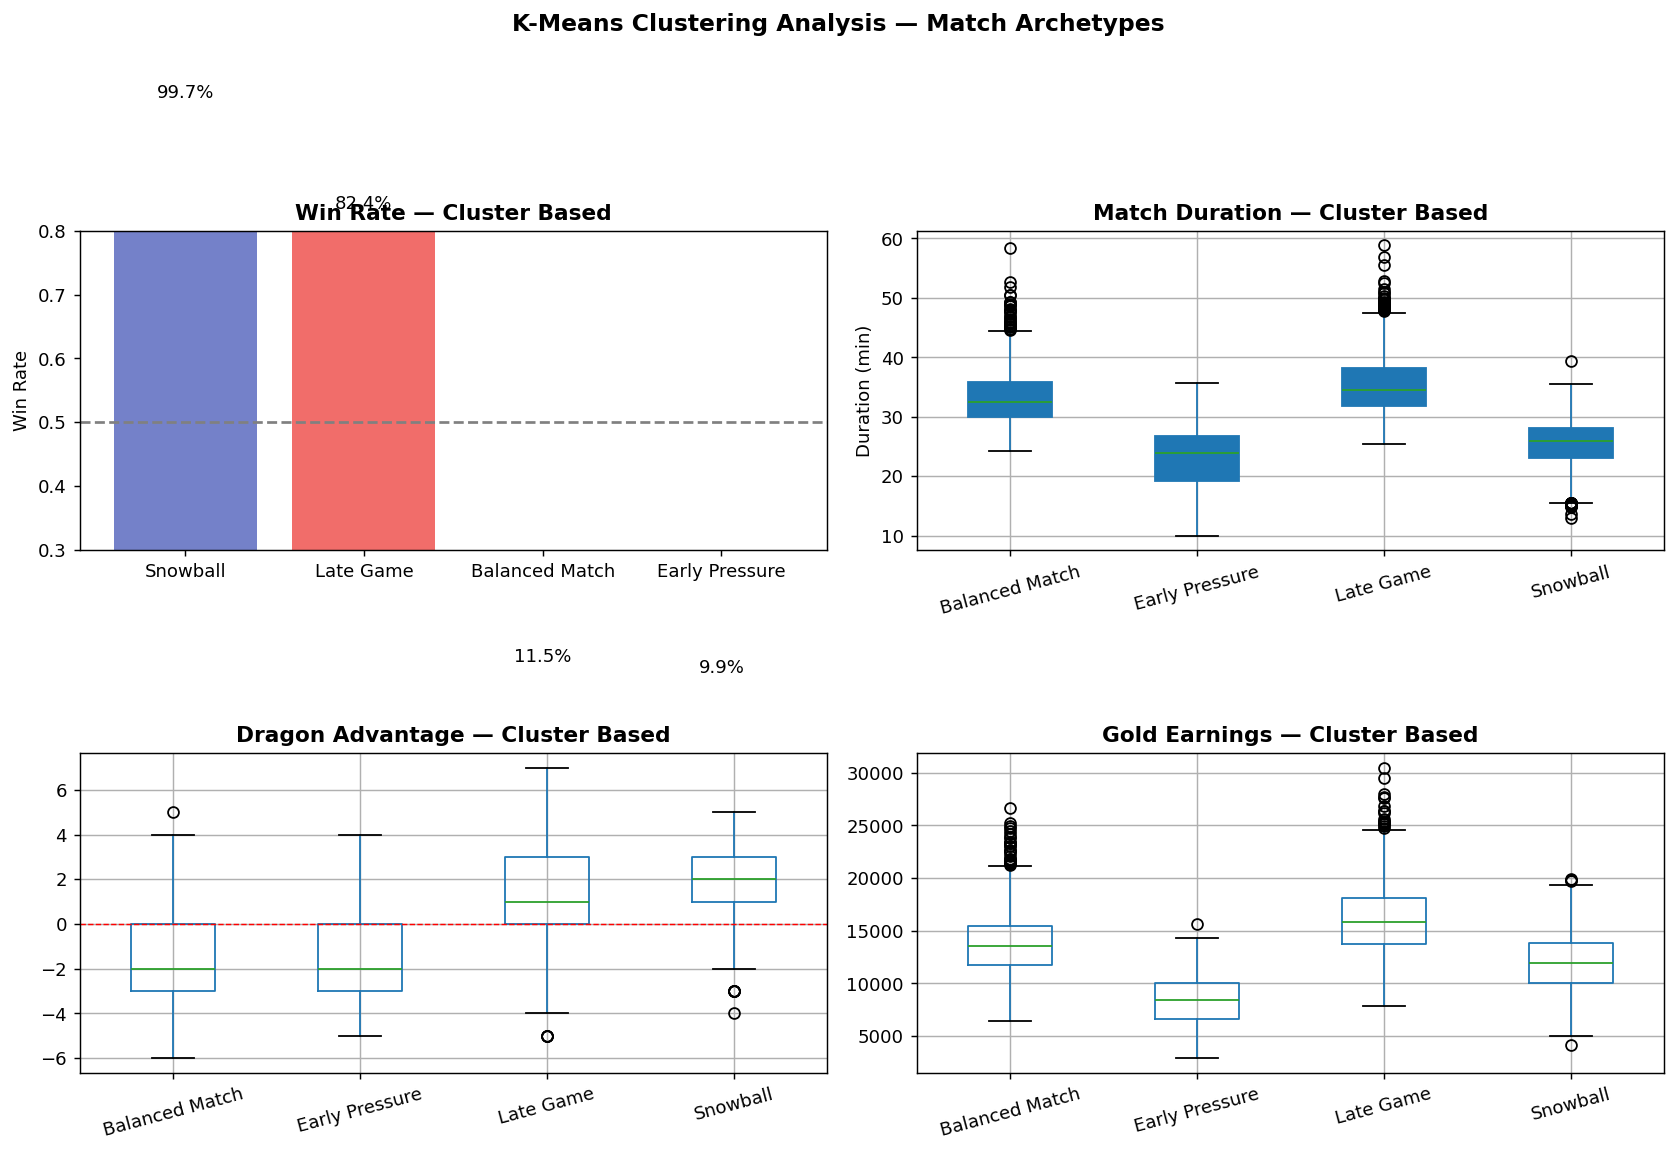

[+] kmeans_clusters.png kaydedildi


In [17]:
# Kümeleri yorumla ve isimlendir — istatistiklere göre değiştir
CLUSTER_NAMES = {
    0: 'Early Pressure',    # Kısa süre, yüksek dragon adv
    1: 'Late Game',       # Uzun süre, baron odaklı
    2: 'Snowball',       # Yüksek gold & kda
    3: 'Balanced Match',    # Ortalama her şey
}
# NOT: Elbow ve cluster_summary'ye bakarak bu isimleri güncelle!

df_cl['cluster_name'] = df_cl['cluster'].map(CLUSTER_NAMES)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette   = ['#5C6BC0', '#EF5350', '#26A69A', '#FFA726']

# Win rate per cluster
ax = axes[0, 0]
wr = df_cl.groupby('cluster_name')['win'].mean().sort_values(ascending=False)
ax.bar(wr.index, wr.values, color=palette[:len(wr)], alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Win Rate — Cluster Based', fontweight='bold')
ax.set_ylabel('Win Rate')
ax.set_ylim(0.3, 0.8)
for i, v in enumerate(wr.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# Duration per cluster
ax = axes[0, 1]
df_cl.boxplot(column='duration_min', by='cluster_name', ax=ax, patch_artist=True)
ax.set_title('Match Duration — Cluster Based', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Duration (min)')
plt.sca(ax); plt.xticks(rotation=15)

# Dragon adv per cluster
ax = axes[1, 0]
df_cl.boxplot(column='dragon_adv', by='cluster_name', ax=ax)
ax.set_title('Dragon Advantage — Cluster Based', fontweight='bold')
ax.set_xlabel('')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.sca(ax); plt.xticks(rotation=15)

# Gold per cluster
ax = axes[1, 1]
df_cl.boxplot(column='gold', by='cluster_name', ax=ax)
ax.set_title('Gold Earnings — Cluster Based', fontweight='bold')
ax.set_xlabel('')
plt.sca(ax); plt.xticks(rotation=15)

plt.suptitle('K-Means Clustering Analysis — Match Archetypes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('[+] kmeans_clusters.png kaydedildi')

### 2.5 Rank Distribution Across Clusters

> Which cluster is more prevalent in which rank?

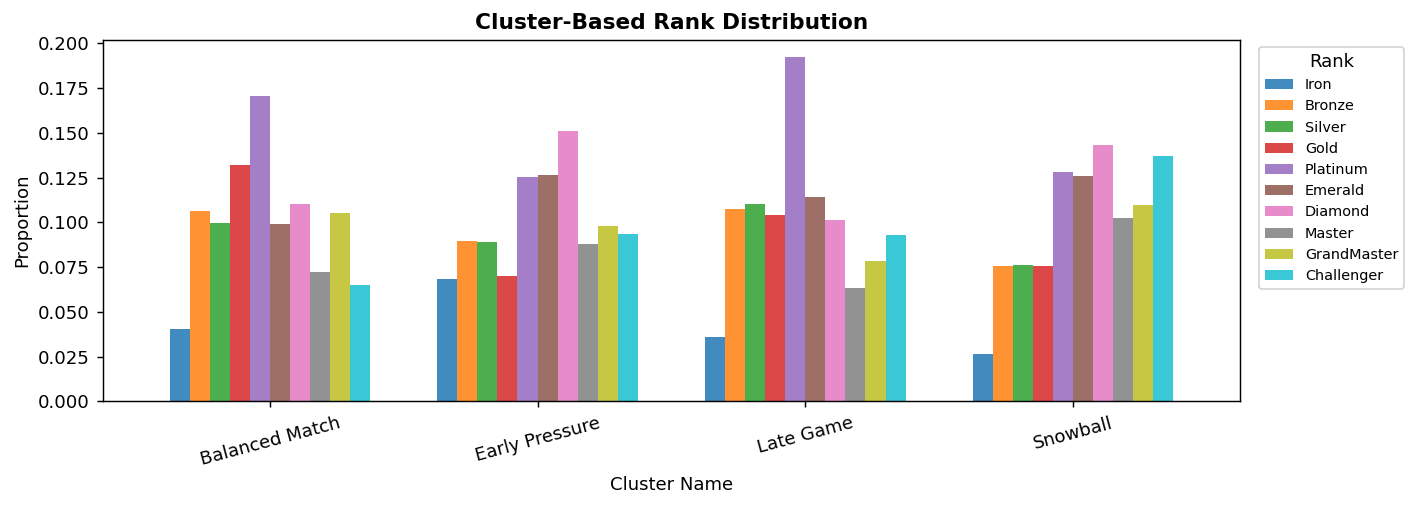

In [18]:
rank_cluster = pd.crosstab(
    df_cl['cluster_name'],
    df_cl['rank'],
    normalize='index'
).reindex(columns=[r for r in RANK_ORDER if r in df_cl['rank'].unique()])

fig, ax = plt.subplots(figsize=(11, 4))
rank_cluster.plot(kind='bar', ax=ax, colormap='tab10', alpha=0.85, width=0.75)
ax.set_title('Cluster-Based Rank Distribution', fontweight='bold')
ax.set_xlabel('Cluster Name')
ax.set_ylabel('Proportion')
ax.legend(title='Rank', bbox_to_anchor=(1.01, 1), fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cluster_rank_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 PCA — 2D Visualization of the Feature Structure

> Let's reduce the high-dimensional feature space to 2 components and visualize the matches.

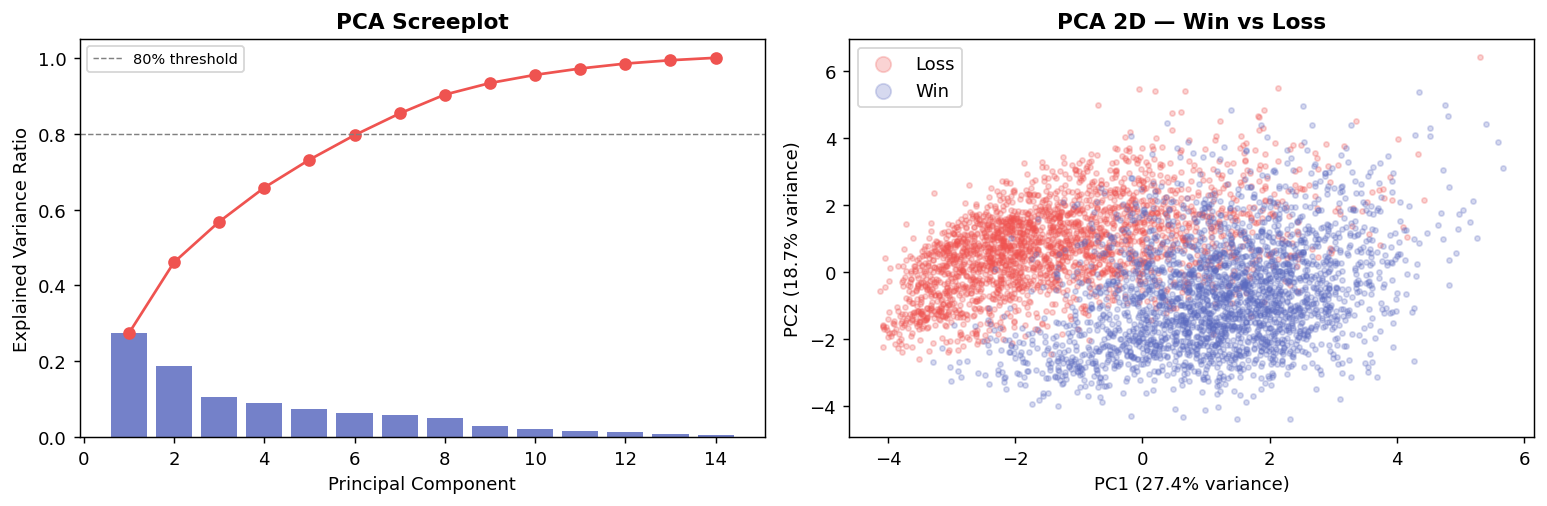

[+] pca_scatter.png kaydedildi


In [19]:
# Supervised feature seti üzerinde PCA
df_pca  = df[FEATURES + ['win', 'rank']].dropna().copy()
X_pca_raw = df_pca[FEATURES].values
X_pca_sc  = StandardScaler().fit_transform(X_pca_raw)

pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_pca_sc)

# Screeplot
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, len(explained)+1), explained, color='#5C6BC0', alpha=0.85)
ax.plot(range(1, len(explained)+1), cumulative, 'o-', color='#EF5350', linewidth=1.5)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Screeplot', fontweight='bold')
ax.legend(fontsize=8)

# 2D scatter — win/loss rengi
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z    = pca2.fit_transform(X_pca_sc)
df_pca['PC1'] = Z[:, 0]
df_pca['PC2'] = Z[:, 1]

ax2 = axes[1]
for win_val, label, color in [(0, 'Loss', '#EF5350'), (1, 'Win', '#5C6BC0')]:
    mask = df_pca['win'] == win_val
    ax2.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                alpha=0.25, s=8, color=color, label=label)
ax2.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax2.set_title('PCA 2D — Win vs Loss', fontweight='bold')
ax2.legend(markerscale=3)

plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()
print('[+] pca_scatter.png kaydedildi')

### 2.7 PCA — Loading Plot

> Which features explain PC1 and PC2 the most?

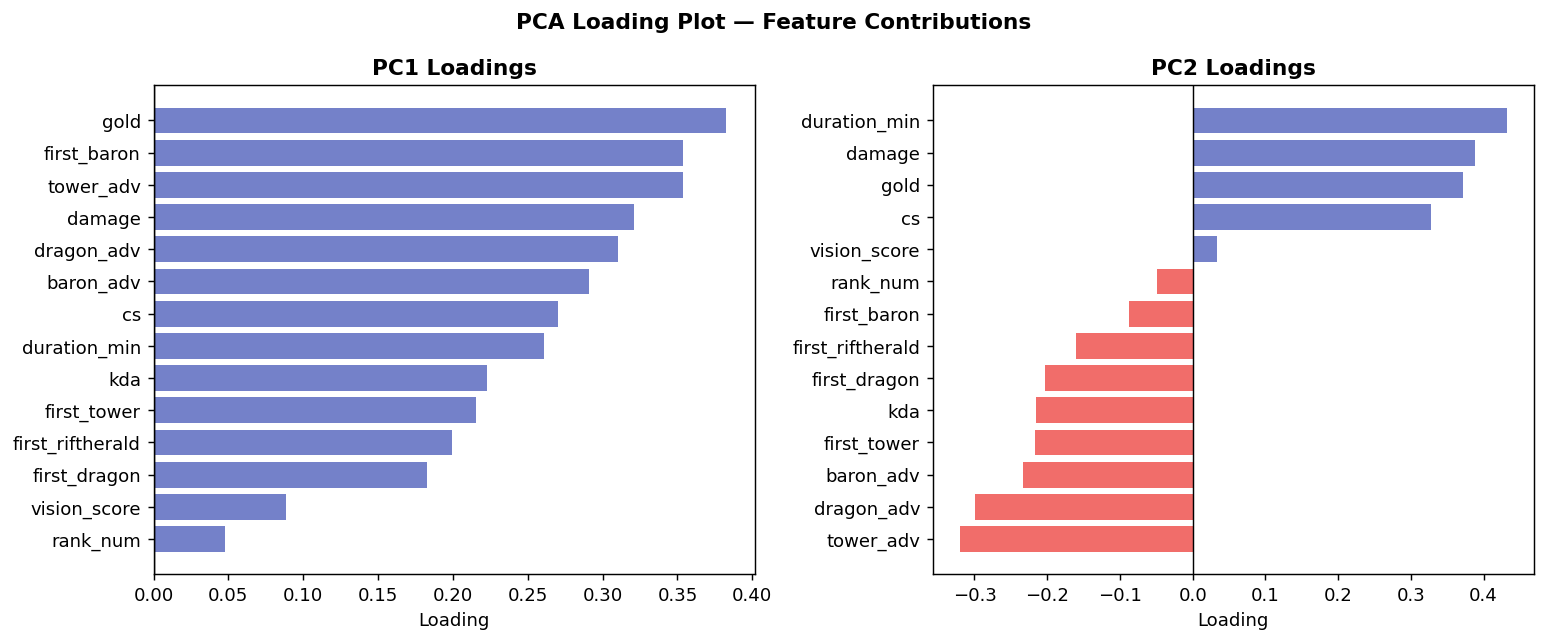

[+] pca_loadings.png kaydedildi


In [20]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2']
).sort_values('PC1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    vals = loadings[pc].sort_values()
    colors_l = ['#EF5350' if v < 0 else '#5C6BC0' for v in vals]
    ax.barh(vals.index, vals.values, color=colors_l, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Loadings', fontweight='bold')
    ax.set_xlabel('Loading')

plt.suptitle('PCA Loading Plot — Feature Contributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150)
plt.show()
print('[+] pca_loadings.png kaydedildi')

### 2.8 PCA + K-Means Together — View of Clusters in 2D Space

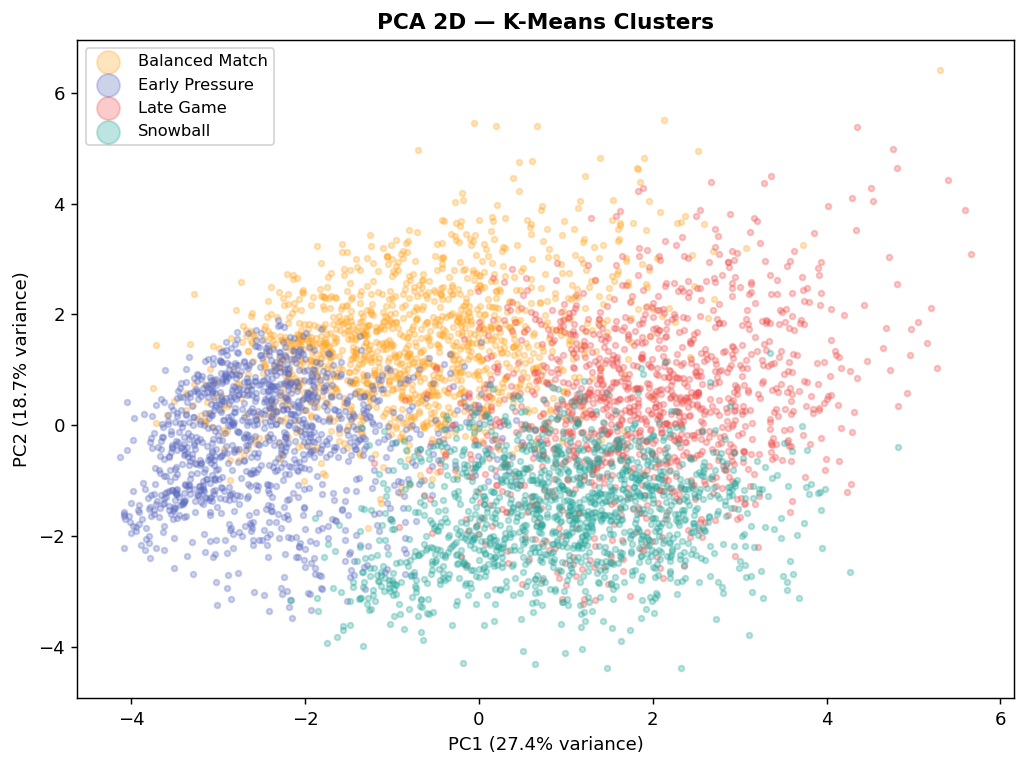

[+] pca_kmeans.png kaydedildi


In [21]:
# df_cl ve df_pca'nın index'i aynı olmalı — ortak index üzerinden merge
df_combined = df_cl[['cluster_name']].join(
    df_pca[['PC1', 'PC2']], how='inner'
)

fig, ax = plt.subplots(figsize=(8, 6))
palette_cl = {'Early Pressure': '#5C6BC0', 'Late Game': '#EF5350',
              'Snowball': '#26A69A', 'Balanced Match': '#FFA726'}

for cname, grp in df_combined.groupby('cluster_name'):
    ax.scatter(grp['PC1'], grp['PC2'],
               alpha=0.3, s=10,
               color=palette_cl.get(cname, '#888'),
               label=cname)

ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax.set_title('PCA 2D — K-Means Clusters', fontweight='bold')
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.savefig('pca_kmeans.png', dpi=150)
plt.show()
print('[+] pca_kmeans.png kaydedildi')

---
## Summary & Findings

### Supervised Learning
- **Best model: Random Forest (highest AUC)
- **Feature importance:** `tower_adv` and `dragon_adv` are the strongest indicators
- **KNN optimal K:** Determined by elbow method
- **Rank based:** The model is less predictive at higher ranks (more balanced matches)

### Unsupervised Learning
- **K-Means 4 Clusters:** Matches are separated into meaningful archetypes
- **PCA:** The first 2 components explain most of the variance; objective features dominate PC1
- **Connection:** Clusters with high win rates align with aggressive objective control